In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f'TensorFlow version: {tf.__version__}')
print(' All libraries imported successfully')

TensorFlow version: 2.20.0
 All libraries imported successfully


In [2]:
# explore dataset

df = pd.read_csv('passenger_count_dataset.csv')

print(' Dataset Shape:', df.shape)
print('\n Columns:', list(df.columns))
print('\n First 5 rows:')
display(df.head())
print('\n Basic Statistics:')
display(df.describe())
print('\n Missing Values:')
print(df.isnull().sum())
print('\n Unique Destinations:', df['Destination'].unique())
print(' Unique Days:', df['Day of Week'].unique())
print(' Unique Time Periods:', df['Time of Day'].unique())

 Dataset Shape: (64260, 11)

 Columns: ['Time', 'Time of Day', 'Day of Week', 'Peak/Off-Peak', 'Holiday/Event', 'Bus Capacity', 'Passenger Count', 'BusStop', 'Destination', 'Lag t-1', 'Lag t-2']

 First 5 rows:


,Time,Time of Day,Day of Week,Peak/Off-Peak,Holiday/Event,Bus Capacity,Passenger Count,BusStop,Destination,Lag t-1,Lag t-2
0,05:00-05:30,Morning,Friday,Off-Peak,No,70,28,Downtown,Batsinda,28.0,28.0
1,05:00-05:30,Morning,Friday,Off-Peak,No,70,76,Downtown,Batsinda,28.0,76.0
2,05:00-05:30,Morning,Friday,Off-Peak,No,70,104,Downtown,Batsinda,76.0,28.0
3,05:00-05:30,Morning,Friday,Off-Peak,No,70,68,Downtown,Batsinda,104.0,76.0
4,05:00-05:30,Morning,Friday,Off-Peak,No,70,50,Downtown,Batsinda,68.0,104.0



 Basic Statistics:


,Bus Capacity,Passenger Count,Lag t-1,Lag t-2
count,64260.0,64260.000000,64260.000000,64260.000000
mean,70.0,106.063492,106.062309,106.062138
std,0.0,44.862650,44.863709,44.863748
min,70.0,12.000000,12.000000,12.000000
25%,70.0,72.000000,72.000000,72.000000
50%,70.0,97.000000,97.000000,97.000000
75%,70.0,135.000000,135.000000,135.000000
max,70.0,255.000000,255.000000,255.000000



 Missing Values:
Time               0
Time of Day        0
Day of Week        0
Peak/Off-Peak      0
Holiday/Event      0
Bus Capacity       0
Passenger Count    0
BusStop            0
Destination        0
Lag t-1            0
Lag t-2            0
dtype: int64

 Unique Destinations: ['Batsinda' 'Kimironko' 'Nyamirambo']
 Unique Days: ['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']
 Unique Time Periods: ['Morning' 'Afternoon' 'Evening']


In [3]:
# data preprocessing

#  Parse time slot numeric hour 
def parse_time_slot(t):
    start = t.split('-')[0]
    h, m = start.split(':')
    return int(h) + int(m) / 60

df['hour_numeric'] = df['Time'].apply(parse_time_slot)

# Label Encoders
le_tod  = LabelEncoder()  
le_dow  = LabelEncoder()   
le_stop = LabelEncoder()   
le_dest = LabelEncoder()   

df['time_of_day_enc']  = le_tod.fit_transform(df['Time of Day'])
df['day_of_week_enc']  = le_dow.fit_transform(df['Day of Week'])
df['peak_enc']         = (df['Peak/Off-Peak'] == 'Peak').astype(int)
df['holiday_enc']      = (df['Holiday/Event'] == 'Yes').astype(int)
df['busstop_enc']      = le_stop.fit_transform(df['BusStop'])
df['destination_enc']  = le_dest.fit_transform(df['Destination'])

# Feature & Target Columns
FEATURE_COLS = [
    'hour_numeric', 'time_of_day_enc', 'day_of_week_enc',
    'peak_enc', 'holiday_enc', 'Bus Capacity',
    'busstop_enc', 'destination_enc',
    'Lag t-1', 'Lag t-2'
]
TARGET_COL = 'Passenger Count'

print('Features used:', FEATURE_COLS)
print('Target:', TARGET_COL)

# Scalers
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[FEATURE_COLS])
y_scaled = scaler_y.fit_transform(df[[TARGET_COL]])

print(f'\n Features scaled. Shape: {X_scaled.shape}')

Features used: ['hour_numeric', 'time_of_day_enc', 'day_of_week_enc', 'peak_enc', 'holiday_enc', 'Bus Capacity', 'busstop_enc', 'destination_enc', 'Lag t-1', 'Lag t-2']
Target: Passenger Count

 Features scaled. Shape: (64260, 10)


In [4]:
# create sequene

SEQ_LEN = 10 
BUS_CAPACITY = 70

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LEN)

print(f' Sequences created:')
print(f'   X_seq shape: {X_seq.shape}  → (samples, timesteps, features)')
print(f'   y_seq shape: {y_seq.shape}  → (samples, 1)')

# ── Train / Test Split (no shuffle — preserves temporal order)
SPLIT = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:SPLIT], X_seq[SPLIT:]
y_train, y_test = y_seq[:SPLIT], y_seq[SPLIT:]

print(f'\n Train size: {len(X_train)} samples')
print(f'Test  size: {len(X_test)} samples')

 Sequences created:
   X_seq shape: (64250, 10, 10)  → (samples, timesteps, features)
   y_seq shape: (64250, 1)  → (samples, 1)

 Train size: 51400 samples
Test  size: 12850 samples


In [5]:
# build neural network

def build_bilstm(seq_len, n_features):
    model = Sequential([
        # First BiLSTM Block
        Bidirectional(
            LSTM(128, return_sequences=True),
            input_shape=(seq_len, n_features)
        ),
        BatchNormalization(),
        Dropout(0.3),

        # Second BiLSTM Block
        Bidirectional(LSTM(64, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.3),

        # Third BiLSTM Block
        Bidirectional(LSTM(32, return_sequences=False)),
        BatchNormalization(),
        Dropout(0.2),

        #Dense Head
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)  # Output: predicted passenger count
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='huber',         
        metrics=['mae']
    )
    return model

model = build_bilstm(SEQ_LEN, len(FEATURE_COLS))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 256)        │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 10, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,969 (1.36 MB)

 Trainable params: 355,073 (1.35 MB)

 Non-trainable params: 896 (3.50 KB)

In [6]:
# train model 

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        'best_bilstm_model.h5',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

print('Training BiLSTM model')
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
print('\n Training complete')

Training BiLSTM model
Epoch 1/60
642/643 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0498 - mae: 0.2206
Epoch 1: val_loss improved from None to 0.00531, saving model to best_bilstm_model.h5



Epoch 1: finished saving model to best_bilstm_model.h5
643/643 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - loss: 0.0214 - mae: 0.1456 - val_loss: 0.0053 - val_mae: 0.0830 - learning_rate: 0.0010
Epoch 2/60
641/643 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0060 - mae: 0.0870
Epoch 2: val_loss improved from 0.00531 to 0.00419, saving model to best_bilstm_model.h5



Epoch 2: finished saving model to best_bilstm_model.h5
643/643 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 0.0057 - mae: 0.0850 - val_loss: 0.0042 - val_mae: 0.0746 - learning_rate: 0.0010
Epoch 3/60
643/643 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0050 - mae: 0.0798
Epoch 3: val_loss improved from 0.00419 to 0.00416, saving model to best_bilstm_model.h5



Epoch 3: finished saving model to best_bilstm_model.h5
643/643 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 0.0048 - mae: 0.0788 - val_loss: 0.0042 - val_mae: 0.0746 - learning_rate: 0.0010
Epoch 4/60
641/643 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0046 - mae: 0.0775
Epoch 4: val_loss did not improve from 0.00416
643/643 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 0.0046 - mae: 0.0772 - val_loss: 0.0049 - val_mae: 0.0797 - learning_rate: 0.0010
Epoch 5/60
642/643 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0045 - mae: 0.0760
Epoch 5: val_loss did not improve from 0.00416
643/643 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 0.0045 - mae: 0.0764 - val_loss: 0.0044 - val_mae: 0.0764 - learning_rate: 0.0010
Epoch 6/60
643/643 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0043 - mae: 0.0755
Epoch 6: val_loss did not improve from 0.00416
643/643 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - loss: 0.0043 - mae: 0.0754 - val_loss: 0.0044 - val_mae: 0.0757 - learning_rate: 0.0010
Epoch 7/60
641/643 ━━━━━━


Epoch 8: finished saving model to best_bilstm_model.h5
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0042 - mae: 0.0746 - val_loss: 0.0041 - val_mae: 0.0739 - learning_rate: 0.0010
Epoch 9/60
642/643 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0042 - mae: 0.0744
Epoch 9: val_loss did not improve from 0.00407
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0042 - mae: 0.0742 - val_loss: 0.0043 - val_mae: 0.0755 - learning_rate: 0.0010
Epoch 10/60
642/643 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0041 - mae: 0.0740
Epoch 10: val_loss did not improve from 0.00407
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - loss: 0.0042 - mae: 0.0742 - val_loss: 0.0047 - val_mae: 0.0778 - learning_rate: 0.0010
Epoch 11/60
643/643 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0042 - mae: 0.0739
Epoch 11: val_loss did not improve from 0.00407
643/643 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 0.0041 - mae: 0.0739 - val_loss: 0.0041 - val_mae: 0.0742 - learning_rate: 0.0010
Epoch 12/60
641/643 ━

...


Epoch 52: finished saving model to best_bilstm_model.h5
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0038 - mae: 0.0712 - val_loss: 0.0039 - val_mae: 0.0728 - learning_rate: 3.1250e-05
Epoch 53/60
643/643 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0037 - mae: 0.0709
Epoch 53: val_loss improved from 0.00391 to 0.00391, saving model to best_bilstm_model.h5



Epoch 53: finished saving model to best_bilstm_model.h5
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0038 - mae: 0.0712 - val_loss: 0.0039 - val_mae: 0.0728 - learning_rate: 3.1250e-05
Epoch 54/60
641/643 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0037 - mae: 0.0709
Epoch 54: val_loss did not improve from 0.00391
643/643 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 0.0038 - mae: 0.0712 - val_loss: 0.0039 - val_mae: 0.0728 - learning_rate: 3.1250e-05
Epoch 55/60
642/643 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0037 - mae: 0.0711
Epoch 55: val_loss did not improve from 0.00391
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0038 - mae: 0.0712 - val_loss: 0.0039 - val_mae: 0.0728 - learning_rate: 3.1250e-05
Epoch 56/60
642/643 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0037 - mae: 0.0711
Epoch 56: val_loss improved from 0.00391 to 0.00391, saving model to best_bilstm_model.h5



Epoch 56: finished saving model to best_bilstm_model.h5
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0038 - mae: 0.0712 - val_loss: 0.0039 - val_mae: 0.0728 - learning_rate: 3.1250e-05
Epoch 57/60
642/643 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0038 - mae: 0.0713
Epoch 57: val_loss did not improve from 0.00391

Epoch 57: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0037 - mae: 0.0711 - val_loss: 0.0039 - val_mae: 0.0728 - learning_rate: 3.1250e-05
Epoch 58/60
641/643 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0038 - mae: 0.0715
Epoch 58: val_loss improved from 0.00391 to 0.00391, saving model to best_bilstm_model.h5



Epoch 58: finished saving model to best_bilstm_model.h5
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0038 - mae: 0.0711 - val_loss: 0.0039 - val_mae: 0.0728 - learning_rate: 1.5625e-05
Epoch 59/60
641/643 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0038 - mae: 0.0714
Epoch 59: val_loss did not improve from 0.00391
643/643 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.0038 - mae: 0.0712 - val_loss: 0.0039 - val_mae: 0.0728 - learning_rate: 1.5625e-05
Epoch 60/60
643/643 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0037 - mae: 0.0710
Epoch 60: val_loss improved from 0.00391 to 0.00390, saving model to best_bilstm_model.h5



Epoch 60: finished saving model to best_bilstm_model.h5
643/643 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 0.0038 - mae: 0.0711 - val_loss: 0.0039 - val_mae: 0.0728 - learning_rate: 1.5625e-05
Restoring model weights from the end of the best epoch: 60.

 Training complete


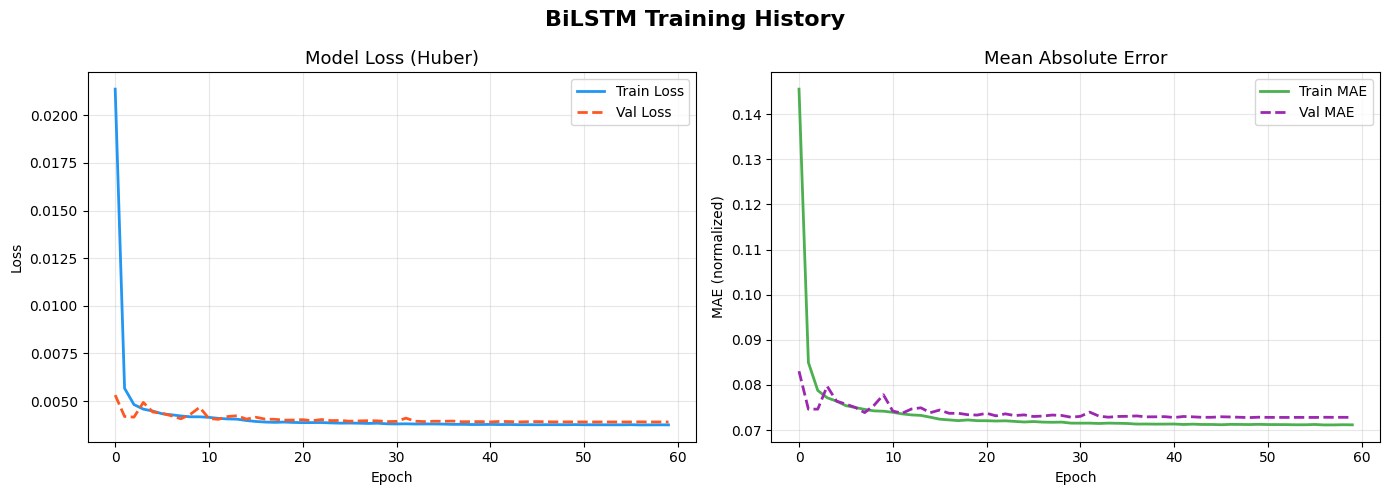

 Saved training_history.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BiLSTM Training History', fontsize=16, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='#2196F3', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#FF5722', lw=2, linestyle='--')
axes[0].set_title('Model Loss (Huber)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'],     label='Train MAE', color='#4CAF50', lw=2)
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#9C27B0', lw=2, linestyle='--')
axes[1].set_title('Mean Absolute Error', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (normalized)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved training_history.png')

In [8]:
# make prediction

# Predict & Inverse Transform
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_actual = scaler_y.inverse_transform(y_test).flatten()

# Clip negatives 
y_pred_actual = np.maximum(y_pred_actual, 0)

# Derived Outputs
buses_actual = np.ceil(y_test_actual / BUS_CAPACITY).astype(int)
buses_pred   = np.ceil(y_pred_actual  / BUS_CAPACITY).astype(int)

print('Sample predictions (first 10):')
results_df = pd.DataFrame({
    'Actual Passengers': y_test_actual[:10].astype(int),
    'Predicted Passengers': y_pred_actual[:10].astype(int),
    'Actual Buses Needed':  buses_actual[:10],
    'Predicted Buses Needed': buses_pred[:10]
})
display(results_df)

Sample predictions (first 10):


,Actual Passengers,Predicted Passengers,Actual Buses Needed,Predicted Buses Needed
0,133,148,2,3
1,155,148,3,3
2,128,148,2,3
3,146,148,3,3
4,160,148,3,3
5,124,148,2,3
6,150,148,3,3
7,126,148,2,3
8,155,148,3,3
9,111,148,2,3


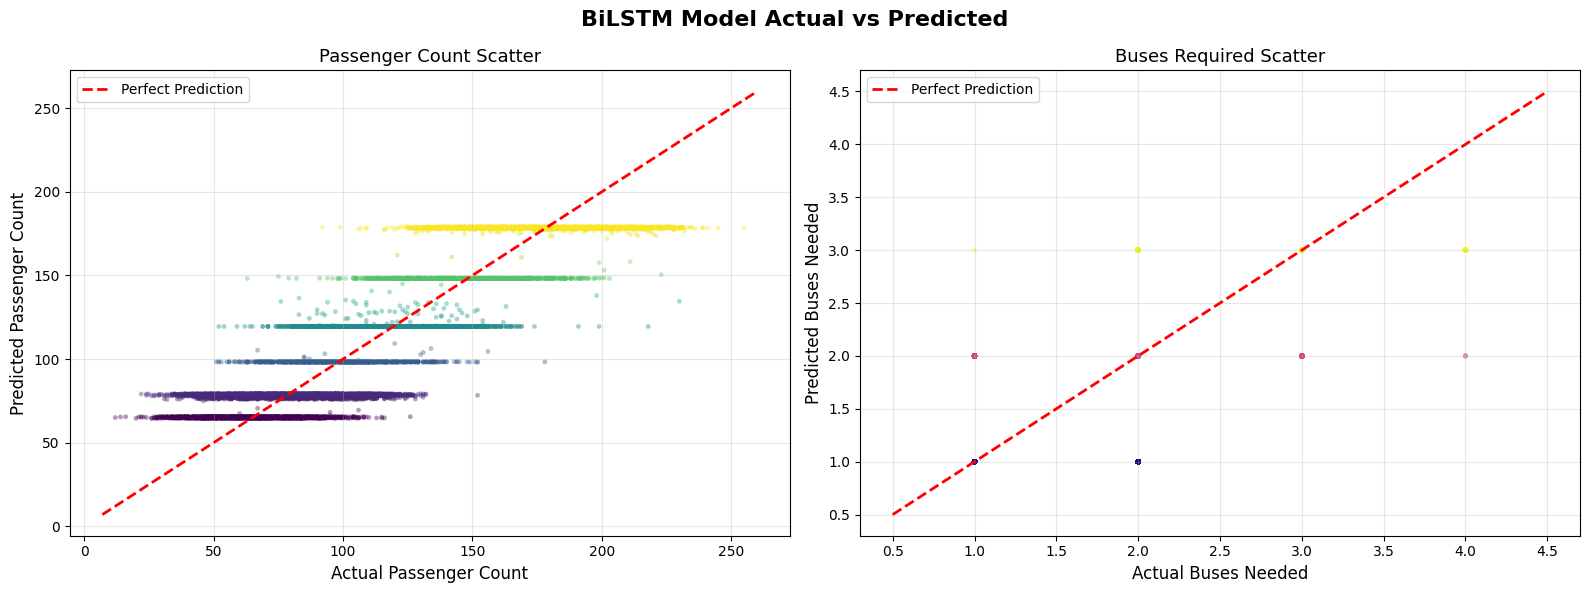

Saved scatter_actual_vs_predicted.png


In [9]:
#scatter plot 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BiLSTM Model Actual vs Predicted', fontsize=16, fontweight='bold')

# Scatter Plot: Passengers
axes[0].scatter(
    y_test_actual, y_pred_actual,
    alpha=0.4, s=12,
    c=y_pred_actual, cmap='viridis', edgecolors='none'
)
lims = [min(y_test_actual.min(), y_pred_actual.min()) - 5,
        max(y_test_actual.max(), y_pred_actual.max()) + 5]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Passenger Count', fontsize=12)
axes[0].set_ylabel('Predicted Passenger Count', fontsize=12)
axes[0].set_title('Passenger Count Scatter', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#Scatter Plot: Buses Needed
axes[1].scatter(
    buses_actual, buses_pred,
    alpha=0.4, s=15,
    c=buses_pred, cmap='plasma', edgecolors='none'
)
lims2 = [min(buses_actual.min(), buses_pred.min()) - 0.5,
         max(buses_actual.max(), buses_pred.max()) + 0.5]
axes[1].plot(lims2, lims2, 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Buses Needed', fontsize=12)
axes[1].set_ylabel('Predicted Buses Needed', fontsize=12)
axes[1].set_title('Buses Required Scatter', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved scatter_actual_vs_predicted.png')

In [10]:
# evaluation metrics

# Bin passengers into demand categories for classification metrics


def bin_demand(count):
    if count <= 50:  return 0   
    elif count <= 100: return 1  
    else: return 2              

y_actual_bins = np.array([bin_demand(c) for c in y_test_actual])
y_pred_bins   = np.array([bin_demand(c) for c in y_pred_actual])

# Classification Metrics
acc   = accuracy_score(y_actual_bins, y_pred_bins)
prec  = precision_score(y_actual_bins, y_pred_bins, average='weighted', zero_division=0)
rec   = recall_score(y_actual_bins, y_pred_bins,    average='weighted', zero_division=0)
f1    = f1_score(y_actual_bins, y_pred_bins,        average='weighted', zero_division=0)

print('=' * 55)
print('       BiLSTM MODEL — EVALUATION METRICS')
print('=' * 55)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print('=' * 55)
print('\n Detailed Classification Report:')
print(classification_report(
    y_actual_bins, y_pred_bins,
    target_names=['Low (0–50)', 'Medium (51–100)', 'High (101+)']
))

# Regression Metrics 
mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)

print('─' * 55)
print('       REGRESSION METRICS (bonus)')
print('─' * 55)
print(f'  MAE  (Mean Absolute Error) : {mae:.2f} passengers')
print(f'  RMSE (Root Mean Sq Error)  : {rmse:.2f} passengers')
print(f'  R²   (R-squared Score)     : {r2:.4f}')
print('─' * 55)

       BiLSTM MODEL — EVALUATION METRICS
  Accuracy  : 0.8011  (80.11%)
  Precision : 0.7607
  Recall    : 0.8011
  F1 Score  : 0.7739

 Detailed Classification Report:
                 precision    recall  f1-score   support

     Low (0–50)       0.00      0.00      0.00       885
Medium (51–100)       0.73      0.92      0.82      6120
    High (101+)       0.91      0.80      0.85      5845

       accuracy                           0.80     12850
      macro avg       0.55      0.57      0.55     12850
   weighted avg       0.76      0.80      0.77     12850

───────────────────────────────────────────────────────
       REGRESSION METRICS (bonus)
───────────────────────────────────────────────────────
  MAE  (Mean Absolute Error) : 17.35 passengers
  RMSE (Root Mean Sq Error)  : 21.07 passengers
  R²   (R-squared Score)     : 0.7772
───────────────────────────────────────────────────────


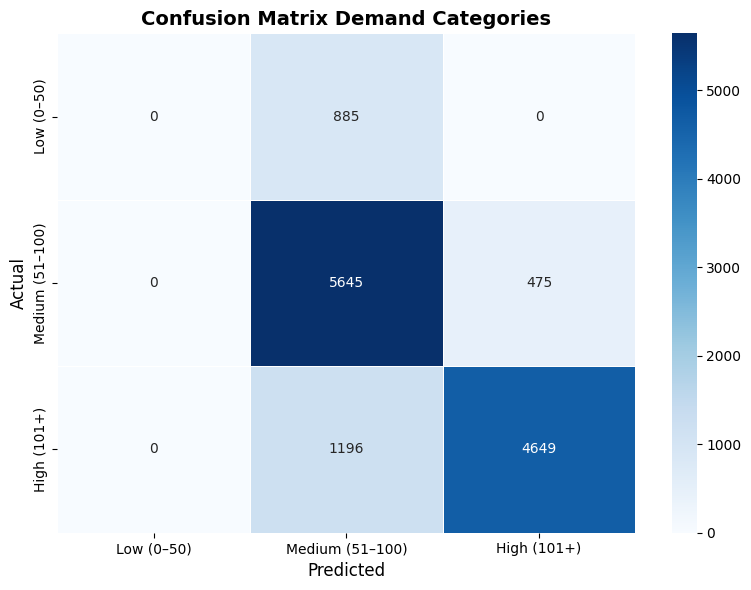

Saved confusion_matrix.png


In [11]:
# confusion matrix

cm = confusion_matrix(y_actual_bins, y_pred_bins)
labels = ['Low (0–50)', 'Medium (51–100)', 'High (101+)']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, linecolor='white'
)
plt.title('Confusion Matrix Demand Categories', fontsize=14, fontweight='bold')
plt.ylabel('Actual',    fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix.png')

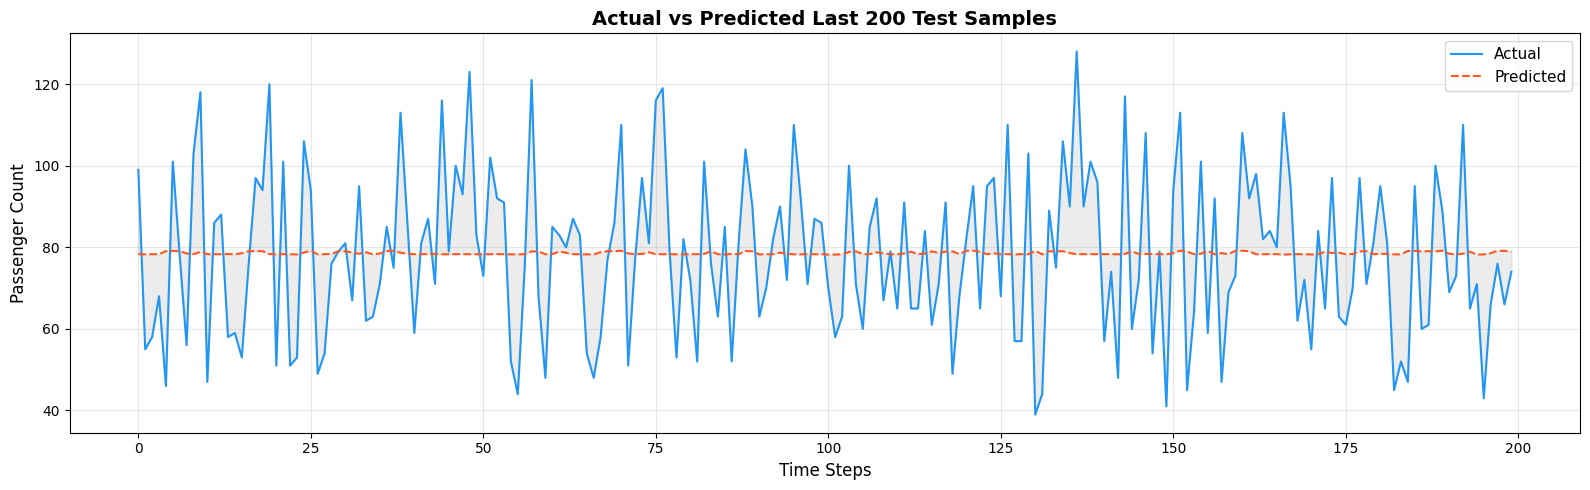

Saved timeseries_forecast.png


In [12]:
# time series fore cast

N = 200 

plt.figure(figsize=(16, 5))
plt.plot(range(N), y_test_actual[-N:],  label='Actual',    color='#2196F3', lw=1.5)
plt.plot(range(N), y_pred_actual[-N:],  label='Predicted', color='#FF5722', lw=1.5, linestyle='--')
plt.fill_between(
    range(N),
    y_test_actual[-N:], y_pred_actual[-N:],
    alpha=0.15, color='gray'
)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.title('Actual vs Predicted Last 200 Test Samples', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('timeseries_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved timeseries_forecast.png')

In [13]:
# multi step interval forecast

def forecast_intervals(model, last_sequence, scaler_X, scaler_y, steps=4):
    """
    Forecasts passenger count for next `steps` time intervals (each = 15 min).
    steps=1 → +15 min, steps=2 → +30 min, steps=3 → +45 min, steps=4 → +60 min
    """
    preds = []
    seq = last_sequence.copy() 

    for _ in range(steps):
        pred_scaled = model.predict(seq, verbose=0)
        pred_val    = scaler_y.inverse_transform(pred_scaled)[0][0]
        pred_val    = max(pred_val, 0)
        preds.append(pred_val)

        # Roll sequence: drop oldest, append new prediction row
        new_row = seq[0, -1, :].copy()
        # Update lag features if present (indices 8 = lag t-1, 9 = lag t-2)
        # Shift: new lag t-2 = old lag t-1, new lag t-1 = predicted 
        old_lag1 = seq[0, -1, 8]
        new_lag1 = pred_scaled[0][0]   # scaled prediction
        new_row[9] = old_lag1
        new_row[8] = new_lag1
        seq = np.concatenate([seq[:, 1:, :], new_row.reshape(1, 1, -1)], axis=1)

    return preds

# Use last test sequence as starting point
sample_seq = X_test[-1:]
interval_preds = forecast_intervals(model, sample_seq, scaler_X, scaler_y, steps=4)

print('\n  Multi-Step Interval Forecast:')
print('─' * 45)
intervals = ['+ 15 min', '+ 30 min', '+ 45 min', '+ 60 min']
for label, val in zip(intervals, interval_preds):
    buses = int(np.ceil(val / BUS_CAPACITY))
    print(f'  {label}: {int(val):>4} passengers  →  {buses} bus(es) needed')
print('─' * 45)


  Multi-Step Interval Forecast:
─────────────────────────────────────────────
  + 15 min:   79 passengers  →  2 bus(es) needed
  + 30 min:   78 passengers  →  2 bus(es) needed
  + 45 min:   78 passengers  →  2 bus(es) needed
  + 60 min:   78 passengers  →  2 bus(es) needed
─────────────────────────────────────────────


In [14]:
# save model 

# Save Keras model
model.save('best_bilstm_model.h5')

# Save scalers and encoders
joblib.dump(scaler_X,  'scaler_X.pkl')
joblib.dump(scaler_y,  'scaler_y.pkl')
joblib.dump(le_tod,    'le_tod.pkl')
joblib.dump(le_dow,    'le_dow.pkl')
joblib.dump(le_stop,   'le_stop.pkl')
joblib.dump(le_dest,   'le_dest.pkl')

# Save feature column names and constants
import json
config = {
    'feature_cols': FEATURE_COLS,
    'seq_len': SEQ_LEN,
    'bus_capacity': BUS_CAPACITY,
    'time_of_day_classes': list(le_tod.classes_),
    'day_of_week_classes':  list(le_dow.classes_),
    'busstop_classes':      list(le_stop.classes_),
    'destination_classes':  list(le_dest.classes_)
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved files:')


Saved files:
